          Date      Time  Device ID  Voltage  Current  Temp Response  \
1    6/26/2026  14:00:30          8     3.90     0.97  38.7       OK   
4    6/26/2026  14:01:15          8     3.99     0.99  38.2       OK   
7    6/26/2026  14:02:00          8     4.00     0.99  37.7       OK   
8    6/26/2026  14:02:15          8     2.65     0.66  37.7       OK   
11   6/26/2026  14:03:00          8     0.19     0.04  37.0       OK   
..         ...       ...        ...      ...      ...   ...      ...   
156  6/26/2026  14:39:15          8     1.89     0.47  34.7       OK   
157  6/26/2026  14:39:30          8     1.88     0.47  34.5       OK   
159  6/26/2026  14:40:00          8     1.92     0.48  34.5       OK   
160  6/26/2026  14:40:15          8     1.92     0.48  35.0       OK   
161  6/26/2026  14:40:15          8     1.92     0.47  34.2       OK   

     Unnamed: 7 Unnamed: 8  
1           NaN      3.783  
4           NaN     3.9501  
7           NaN       3.96  
8           NaN    

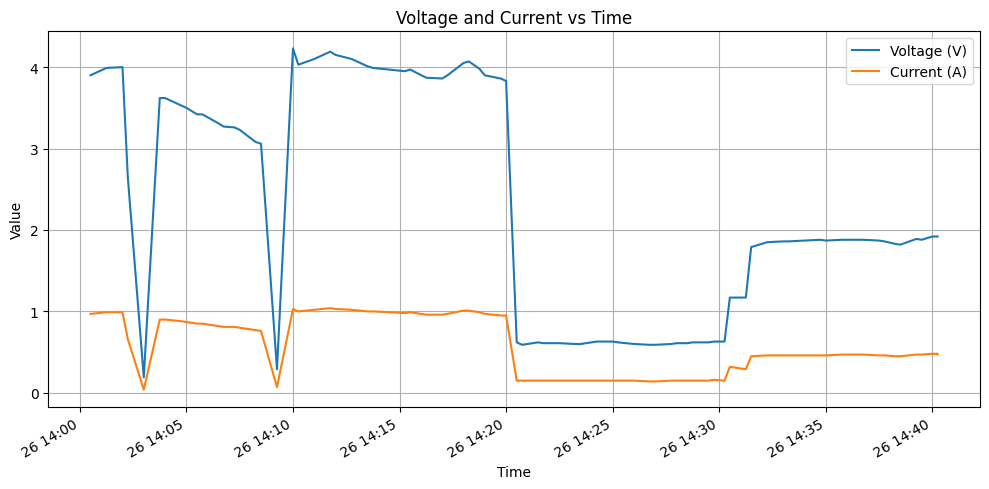

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data (replace with your file path)
df = pd.read_csv("spo26_177.csv")
# Remove NO RESPONSE rows
df = df[df["Response"] == "OK"]
print(df)
# Drop rows with NA values (just in case)
# df = df.dropna()
# Convert Time column to datetime
df["DateTime"] = pd.to_datetime(df["Date"] + " " + df["Time"])

# Convert Voltage and Current to numeric
# df["Voltage"] = pd.to_numeric(df["Voltage"])
# df["Current"] = pd.to_numeric(df["Current"])
# print(df"])

df = df[df["Response"] == "OK"].copy()
df["DateTime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
# df["Voltage"] = pd.to_numeric(df["Voltage"], errors="coerce")
# df["Current"] = pd.to_numeric(df["Current"], errors="coerce")
# df = df.dropna(subset=["DateTime", "Voltage", "Current"])

# Single-axis plot
plt.figure(figsize=(10,5))
plt.plot(df["DateTime"], df["Voltage"], label="Voltage (V)")
plt.plot(df["DateTime"], df["Current"], label="Current (A)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Voltage and Current vs Time")
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

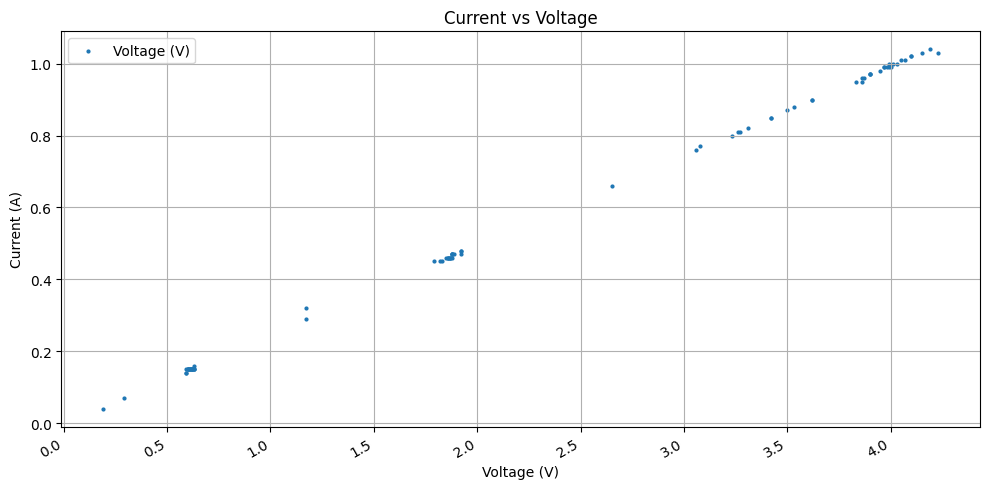

In [3]:
# Single-axis plot
plt.figure(figsize=(10,5))
plt.scatter(df["Voltage"], df["Current"], label="Voltage (V)",s=4)
plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Current vs Voltage")
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

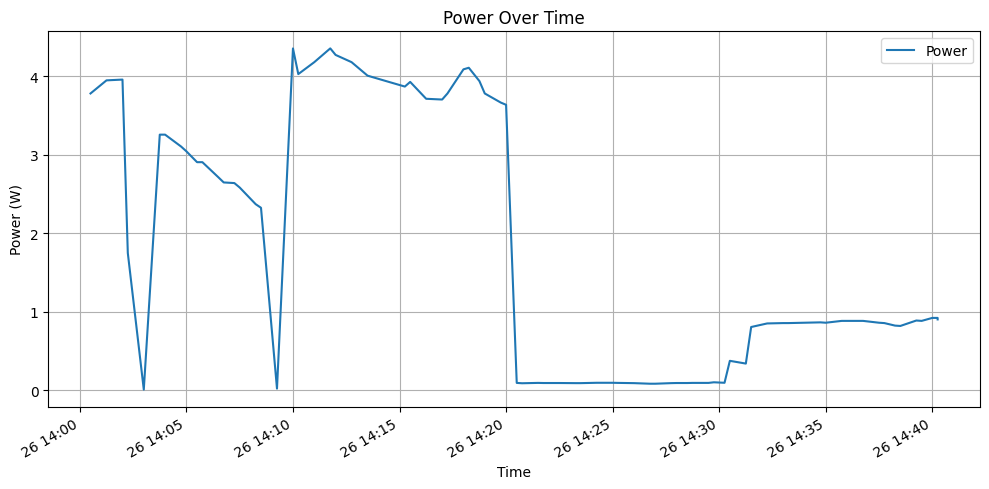

In [4]:
plt.figure(figsize=(10,5))
power = df["Voltage"] * df["Current"]
plt.plot(df["DateTime"], power, label="Power")
plt.xlabel("Time")
plt.ylabel("Power (W)")
plt.title("Power Over Time")
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

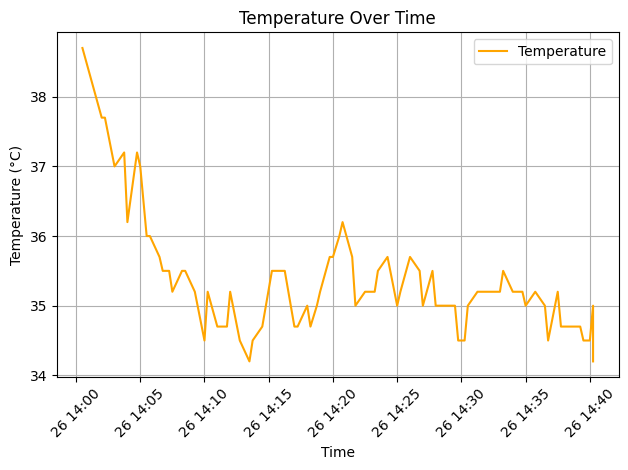

In [5]:
plt.figure(figsize=(10,5))

temperature = df["Temp"]
plt.figure()
plt.plot(df["DateTime"], temperature, label="Temperature", color="orange")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()